In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
train_df = pd.read_csv("../data/processed/eda_df.csv")

In [3]:
train_df

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,1,13,0,1,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,1,0,25,1,2,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,0,1,26,1,2,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,0,1,25,1,2,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,1,1,61,1,2,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,0,0,23,1,0,192,2,1,2,3,...,2,3,1,4,2,3,2,3,0.0,0
103900,1,1,49,1,2,2347,4,4,4,4,...,5,5,5,5,5,5,4,0,0.0,1
103901,1,0,30,1,2,1995,1,1,1,3,...,4,3,2,4,5,5,4,7,14.0,0
103902,0,0,22,1,0,1000,1,1,1,5,...,1,4,5,1,5,4,1,0,0.0,0


# Preprocessing

## Xử lý missing values

In [4]:
train_df.isnull().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction                           0
dtype: int64

In [5]:
# Tính hệ số tương quan giữa 2 cột 
corr_value = train_df['Departure Delay in Minutes'].corr(train_df['Arrival Delay in Minutes'])
print(f"Hệ số tương quan giữa Arrival Delay in Min và Departure Delay in Min: {corr_value}")

Hệ số tương quan giữa Arrival Delay in Min và Departure Delay in Min: 0.9654809013755733


Hệ số tương quan rất cao giữa cột "Departure Delay in Minutes" và cột "Arrival Delay in Minutes" nên em sẽ drop cột "Arrival Delay in Minutes" vì cột đó có missing values.


In [6]:
train_df = train_df.drop(columns=['Arrival Delay in Minutes'])

In [7]:
test_df = pd.read_csv("../data/raw/test.csv")
test_df = test_df.drop(columns=['Arrival Delay in Minutes'])
test_df

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,3,5,5,5,5,2,5,5,50,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,5,4,4,4,4,3,4,5,0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,2,4,1,3,2,2,2,0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,4,1,1,1,1,3,1,4,0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,2,4,2,4,0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,25971,78463,Male,disloyal Customer,34,Business travel,Business,526,3,3,...,4,4,3,2,4,4,5,4,0,neutral or dissatisfied
25972,25972,71167,Male,Loyal Customer,23,Business travel,Business,646,4,4,...,4,4,4,5,5,5,5,4,0,satisfied
25973,25973,37675,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,...,2,2,4,3,4,5,4,2,0,neutral or dissatisfied
25974,25974,90086,Male,Loyal Customer,14,Business travel,Business,1127,3,3,...,4,4,3,2,5,4,5,4,0,satisfied


In [8]:
def label_encoding_for_test_data(test_df):
    test_df = test_df.drop(columns = ["Unnamed: 0", "id"])
    test_df["Type of Travel"] = test_df["Type of Travel"].map({"Business travel": 1, "Personal Travel": 0})
    test_df["Class"] = test_df["Class"].map({"Business": 2, "Eco": 0, "Eco Plus": 1})
    test_df["Gender"] = test_df["Gender"].map({"Male": 1, "Female": 0})
    test_df["Customer Type"] = test_df["Customer Type"].map({"Loyal Customer": 1, "disloyal Customer": 0})
    test_df["satisfaction"] = test_df["satisfaction"].map({"satisfied": 1, "neutral or dissatisfied": 0})
    return test_df

In [9]:
test_df = label_encoding_for_test_data(test_df)
print(test_df)

       Gender  Customer Type  Age  Type of Travel  Class  Flight Distance  \
0           0              1   52               1      0              160   
1           0              1   36               1      2             2863   
2           1              0   20               1      0              192   
3           1              1   44               1      2             3377   
4           0              1   49               1      0             1182   
...       ...            ...  ...             ...    ...              ...   
25971       1              0   34               1      2              526   
25972       1              1   23               1      2              646   
25973       0              1   17               0      0              828   
25974       1              1   14               1      2             1127   
25975       0              1   42               0      0              264   

       Inflight wifi service  Departure/Arrival time convenient  \
0       

# Feature Engineering

In [10]:
X_train = train_df.drop(columns=['satisfaction'])
y_train = train_df['satisfaction']

X_test = test_df.drop(columns=['satisfaction'])
y_test = test_df['satisfaction']

Vì chủ yếu mình dùng model tree-based nên trước mắt e cũng ko feature engineer nhiều và cũng ko normalize vì model tree-based có thể ko bị bias nếu ko normalize.

# Model construction

### Base model

Note tạm:
Có nhiều model nhưng trước hết thì cứ phải có decision tree, random for, adaboost, gradient boost, xgboost, lightgbm (tại mình học :))

In [ ]:
# from sklearn.metrics import accuracy_score 
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import (
#     RandomForestClassifier, 
#     AdaBoostClassifier,
#     GradientBoostingClassifier
# )
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier

# # Tạo baseline model
# baseline_models = {
#     "DecisionTree": DecisionTreeClassifier(random_state= 42),
#     "RandomForestClassifier": RandomForestClassifier(random_state= 42),
#     "AdaBoost": AdaBoostClassifier(random_state= 42, algorithm= "SAMME"),
#     "GradientBoost": GradientBoostingClassifier(random_state= 42),
#     "XGBoost": XGBClassifier(random_state = 42, eval_metrics = 'logloss'),
#     "LightGBM": LGBMClassifier(random_state= 42, verbosity = -1)
# }

# results = {}

# for name, model in baseline_models.items():
#     
#     model.fit(X_train, y_train)
    
#     
#     y_pred = model.predict(X_test)
    
#     
#     acc = accuracy_score(y_test, y_pred)
    

#     results[name] = acc
#     print(f"[{name}] Accuracy: {acc:.4f}")

Em tìm hiểu thì ngoài những thuật toán mình học ra thì còn có CatBoost, ExtraTree và HistGradientBoost nên em thêm vào luôn để tiện đánh giá model

In [ ]:
from sklearn.metrics import accuracy_score 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    AdaBoostClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,            
    HistGradientBoostingClassifier 
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Tạo baseline model
baseline_models = {
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42),              
    "AdaBoost": AdaBoostClassifier(random_state=42, algorithm="SAMME"),
    "GradientBoost": GradientBoostingClassifier(random_state=42),
    "HistGradientBoost": HistGradientBoostingClassifier(random_state=42), 
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),  
    "LightGBM": LGBMClassifier(random_state=42, verbosity=-1),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=False)     
}

results = {}


print("-" * 50)

for name, model in baseline_models.items():

    model.fit(X_train, y_train)
    
   
    y_pred = model.predict(X_test)
    
    
    acc = accuracy_score(y_test, y_pred)
    
    
    results[name] = acc
    print(f"[{name}] Accuracy: {acc:.4f}")

# Sắp xếp thứ hạng
print("\n" + "=" * 50)

print("=" * 50)
for rank, (name, acc) in enumerate(sorted(results.items(), key=lambda x: x[1], reverse=True), 1):
    print(f"Top {rank}: {name:<18} - Accuracy: {acc:.4f}")

--------------------------------------------------
[DecisionTree] Accuracy: 0.9466
[RandomForest] Accuracy: 0.9629
[ExtraTrees] Accuracy: 0.9615
[AdaBoost] Accuracy: 0.9108
[GradientBoost] Accuracy: 0.9421
[HistGradientBoost] Accuracy: 0.9643
[XGBoost] Accuracy: 0.9642
[LightGBM] Accuracy: 0.9634
[CatBoost] Accuracy: 0.9641

Top 1: HistGradientBoost  - Accuracy: 0.9643
Top 2: XGBoost            - Accuracy: 0.9642
Top 3: CatBoost           - Accuracy: 0.9641
Top 4: LightGBM           - Accuracy: 0.9634
Top 5: RandomForest       - Accuracy: 0.9629
Top 6: ExtraTrees         - Accuracy: 0.9615
Top 7: DecisionTree       - Accuracy: 0.9466
Top 8: GradientBoost      - Accuracy: 0.9421
Top 9: AdaBoost           - Accuracy: 0.9108


# Chạy từ đây lên nha các anh :))

Nhận xét:
- Cả 5 thuật toán HistGradientBoost, Random Forest, CatBoost, XGBoost, LightGBM  đều cho ra kết quả cao (> 96%) --> Các thuật toán tree-based phù hợp với dữ liệu hiện tại
Như mn có thể thấy thì 5 thuật toán trên perform tốt nhất nên em sẽ dùng GridSearch như là một cách để tìm ra một bộ tham số tốt nhất cho model xong sau đó sẽ dùng optuna để mở rộng thêm. 


### GridSearch và K-fold để tinh chỉnh

In [27]:
from sklearn.model_selection import GridSearchCV, KFold
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import HistGradientBoostingClassifier
from catboost import CatBoostClassifier

# ==========================================
# 1. XGBOOST
# ==========================================
xgb_params_grid = {
    'max_depth': [5, 7, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 500, 1000] 
}
xgb_base = XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    tree_method='hist',
    device='cuda'
)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_params_grid,
    cv=kf,
    scoring='accuracy',
    n_jobs=1,             
    verbose=2
)
print("Đang chạy Grid Search cho XGBoost...")
grid_search_xgb.fit(X_train, y_train)
print("Best params for XGBoost: ", grid_search_xgb.best_params_)

best_model_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_model_xgb.predict(X_test)
print(f"XGBoost Test Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}\n")




Đang chạy Grid Search cho XGBoost...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=200; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=500; total time=   0.7s
[CV] END .

In [28]:
# ==========================================
# 2. LIGHTGBM
# ==========================================
lgbm_param_grid = {
    'n_estimators': [100, 200, 500, 1000],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [5, 7, 9],
    'num_leaves': [31, 50, 100]
}
lgbm_base = LGBMClassifier(    # Đã sửa lỗi chính tả lggm_base -> lgbm_base
    random_state=42, 
    verbosity=-1,
    device_type='gpu'                
)

grid_search_lgbm = GridSearchCV(
    estimator=lgbm_base,
    param_grid=lgbm_param_grid,
    cv=kf,
    scoring='accuracy',
    n_jobs=1,                         
    verbose=2
)
print("Đang chạy Grid Search cho LightGBM...")
grid_search_lgbm.fit(X_train, y_train)
print("Best params for LightGBM: ", grid_search_lgbm.best_params_) # Đã sửa câu print

best_model_lgbm = grid_search_lgbm.best_estimator_
y_pred_lgbm = best_model_lgbm.predict(X_test)
print(f"LightGBM Test Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}\n")




Đang chạy Grid Search cho LightGBM...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END learning_rate=0.01, max_depth=5, n_estimators=100, num_leaves=31; total time=   0.7s
[CV] END learning_rate=0.01, max_depth=5, n_estimators=100, num_leaves=31; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=5, n_estimators=100, num_leaves=31; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=5, n_estimators=100, num_leaves=31; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=5, n_estimators=100, num_leaves=31; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=5, n_estimators=100, num_leaves=50; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=5, n_estimators=100, num_leaves=50; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=5, n_estimators=100, num_leaves=50; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=5, n_estimators=100, num_leaves=50; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=5, n_estimator

In [ ]:
# ==========================================
# 3. RANDOM FOREST
# ==========================================
param_grid_rf = {
    'n_estimators': [100, 200, 500, 1000],
    'max_depth': [None, 10, 20],     
    'min_samples_split': [2, 5, 10]   
}

rf_base = RandomForestClassifier(random_state=42)

grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=kf,
    scoring='accuracy',
    n_jobs=-1,             
    verbose=2
)
print("Đang chạy Grid Search cho Random Forest...")
grid_search_rf.fit(X_train, y_train)
print("Best params for Random Forest: ", grid_search_rf.best_params_)

best_model_rf = grid_search_rf.best_estimator_
y_pred_rf = best_model_rf.predict(X_test)
print(f"Random Forest Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

Đang chạy Grid Search cho Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params for Random Forest:  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 500}
Random Forest Test Accuracy: 0.9638


In [30]:
# ==========================================
# 4. HIST GRADIENT BOOSTING
# ==========================================
hist_param_grid = {
    'max_iter': [100, 200, 500, 1000],     # max_iter tương đương với n_estimators
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [None, 5, 7, 9]           # None cho phép cây mọc tự do
}

hist_base = HistGradientBoostingClassifier(random_state=42)

grid_search_hist = GridSearchCV(
    estimator=hist_base,
    param_grid=hist_param_grid,
    cv=kf,
    scoring='accuracy',
    n_jobs=-1,                             # HistGradientBoost chạy trên CPU, để -1 vắt kiệt đa luồng
    verbose=2
)
print("\nĐang chạy Grid Search cho HistGradientBoost...")
grid_search_hist.fit(X_train, y_train)
print("Best params for HistGradientBoost: ", grid_search_hist.best_params_)

best_model_hist = grid_search_hist.best_estimator_
y_pred_hist = best_model_hist.predict(X_test)
print(f"HistGradientBoost Test Accuracy: {accuracy_score(y_test, y_pred_hist):.4f}\n")


Đang chạy Grid Search cho HistGradientBoost...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params for HistGradientBoost:  {'learning_rate': 0.1, 'max_depth': None, 'max_iter': 200}
HistGradientBoost Test Accuracy: 0.9649



In [31]:
# ==========================================
# 5. CATBOOST
# ==========================================
cat_param_grid = {
    'iterations': [100, 200, 500, 1000],   # iterations tương đương với n_estimators
    'learning_rate': [0.01, 0.1, 0.2],
    'depth': [5, 7, 9]                     # depth tương đương với max_depth
}

cat_base = CatBoostClassifier(
    random_seed=42, 
    task_type='GPU',                       # Ép CatBoost cày bằng card 24GB VRAM
    verbose=False                          # Tắt các thông báo in ra liên tục của CatBoost
)

grid_search_cat = GridSearchCV(
    estimator=cat_base,
    param_grid=cat_param_grid,
    cv=kf,
    scoring='accuracy',
    n_jobs=1,                              # Bắt buộc để 1 khi dùng GPU để tránh tràn VRAM
    verbose=2
)
print("Đang chạy Grid Search cho CatBoost...")
grid_search_cat.fit(X_train, y_train)
print("Best params for CatBoost: ", grid_search_cat.best_params_)

best_model_cat = grid_search_cat.best_estimator_
y_pred_cat = best_model_cat.predict(X_test)
print(f"CatBoost Test Accuracy: {accuracy_score(y_test, y_pred_cat):.4f}")

Đang chạy Grid Search cho CatBoost...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END ........depth=5, iterations=100, learning_rate=0.01; total time=   9.3s
[CV] END ........depth=5, iterations=100, learning_rate=0.01; total time=   0.7s
[CV] END ........depth=5, iterations=100, learning_rate=0.01; total time=   0.7s
[CV] END ........depth=5, iterations=100, learning_rate=0.01; total time=   0.7s
[CV] END ........depth=5, iterations=100, learning_rate=0.01; total time=   0.7s
[CV] END .........depth=5, iterations=100, learning_rate=0.1; total time=   0.7s
[CV] END .........depth=5, iterations=100, learning_rate=0.1; total time=   0.7s
[CV] END .........depth=5, iterations=100, learning_rate=0.1; total time=   0.7s
[CV] END .........depth=5, iterations=100, learning_rate=0.1; total time=   0.7s
[CV] END .........depth=5, iterations=100, learning_rate=0.1; total time=   0.7s
[CV] END .........depth=5, iterations=100, learning_rate=0.2; total time=   0.7s
[CV] END 

In [34]:
import joblib 
import os                  
os.makedirs('saved_model', exist_ok = True)
joblib.dump(best_model_xgb, 'saved_model/best_xgb_model.joblib')
joblib.dump(best_model_lgbm, 'saved_model/best_lgbm_model.joblib')
joblib.dump(best_model_rf, 'saved_model/best_rf_model.joblib')
joblib.dump(best_model_hist, 'saved_model/best_hist_model.joblib')
joblib.dump(best_model_cat, 'saved_model/best_cat_model.joblib')

['saved_model/best_cat_model.joblib']

Đây là những best model của từng loại và mn có thể load lên để predict để tránh mất model.

In [ ]:
print(grid_search_xgb.best_params_)


{'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200}

### Optuna Parameter Tuning

In [ ]:
import optuna
import numpy as np
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings('ignore')

def objective(trial):
    param = {
        'device': 'cuda',
        'tree_method': 'hist',
        'eval_metric': 'logloss',
        'random_state': 42,
        
        'n_estimators': trial.suggest_int('n_estimators', 100, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True)
    }

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []
    
    for train_idx, val_idx in kf.split(X_train, y_train):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        model = XGBClassifier(**param)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        
        preds = model.predict(X_val)
        cv_scores.append(accuracy_score(y_val, preds))

    return np.mean(cv_scores)

# Tạo database để lưu tham số của từng lần chạy
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='XGBoost_Overnight_Tuning',
    storage='sqlite:///optuna_overnight.db', 
    load_if_exists=True
)

# truyền tham số tối ưu từ gridsearch để tìm nhanh hơn.
best_grid_params = {
    'learning_rate': 0.1, 
    'max_depth': 9, 
    'n_estimators': 200
}

# Ép Optuna phải chạy bộ này đầu tiên (Trial 0)
study.enqueue_trial(best_grid_params)

print("Đã truyền mồi. Bắt đầu cày 300 vòng Optuna ")

study.optimize(objective, n_trials=300, show_progress_bar=True)

print("\n" + "="*50)

print(f"Accuracy cao nhất: {study.best_value:.4f}")
print("Tham số siêu việt:", study.best_params)

# Tự động train model xịn nhất và lưu lại luôn
ultimate_model = XGBClassifier(**study.best_params, device='cuda', tree_method='hist', random_state=42)
ultimate_model.fit(X_train, y_train)
joblib.dump(ultimate_model, 'saved_model/ultimate_xgboost_optuna.joblib')
print("Đã tự động lưu vào saved_model/ultimate_xgboost_optuna.joblib!")

[I 2026-09-01 01:36:31,484] Using an existing study with name 'XGBoost_Overnight_Tuning' instead of creating a new one.


Đã truyền mồi. Bắt đầu cày 300 vòng Optuna qua đêm...


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-09-01 01:36:34,143] Trial 29 finished with value: 0.9640725964836374 and parameters: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 9, 'min_child_weight': 5, 'subsample': 0.6831647935362113, 'colsample_bytree': 0.8065525328358796, 'gamma': 2.578339653705013, 'reg_alpha': 0.18300053640667727, 'reg_lambda': 0.007111121442953191}. Best is trial 22 with value: 0.9656413501283077.
[I 2026-09-01 01:37:09,073] Trial 30 finished with value: 0.9634855212887651 and parameters: {'n_estimators': 2111, 'learning_rate': 0.005840885248981857, 'max_depth': 16, 'min_child_weight': 7, 'subsample': 0.7537792491208433, 'colsample_bytree': 0.5705772145796405, 'gamma': 3.8214774989282336, 'reg_alpha': 2.3098518427923302, 'reg_lambda': 0.011196583293712809}. Best is trial 22 with value: 0.9656413501283077.
[I 2026-09-01 01:37:39,373] Trial 31 finished with value: 0.965371875518 and parameters: {'n_estimators': 2672, 'learning_rate': 0.010605237041098935, 'max_depth': 19, 'min_child_weight':

In [38]:
print("1. Best params LightGBM:", grid_search_lgbm.best_params_)
print("2. Best params Random Forest:", grid_search_rf.best_params_)
print("3. Best params HistGradientBoost:", grid_search_hist.best_params_)
print("4. Best params CatBoost:", grid_search_cat.best_params_)

1. Best params LightGBM: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200, 'num_leaves': 31}
2. Best params Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 500}
3. Best params HistGradientBoost: {'learning_rate': 0.1, 'max_depth': None, 'max_iter': 200}
4. Best params CatBoost: {'depth': 9, 'iterations': 200, 'learning_rate': 0.1}


In [ ]:
import optuna
import numpy as np
import joblib
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('saved_model', exist_ok=True)

# Dùng chung một cấu hình K-Fold cho công bằng
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# 1. LIGHTGBM
# ==========================================
print("\n[1/4] BẮT ĐẦU TỐI ƯU LIGHTGBM...")
def obj_lgbm(trial):
    param = {
        'device_type': 'gpu',
        'verbosity': -1,
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'num_leaves': trial.suggest_int('num_leaves', 31, 256),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }
    cv_scores = []
    for train_idx, val_idx in kf.split(X_train, y_train):
        model = LGBMClassifier(**param)
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        cv_scores.append(accuracy_score(y_train.iloc[val_idx], model.predict(X_train.iloc[val_idx])))
    return np.mean(cv_scores)

study_lgbm = optuna.create_study(direction='maximize', study_name='LGBM_Tuning', storage='sqlite:///optuna_lgbm.db', load_if_exists=True)
# ---> THAY KẾT QUẢ GRID SEARCH LIGHTGBM VÀO ĐÂY <---
best_lgbm_params = {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 9, 'num_leaves': 31} 
study_lgbm.enqueue_trial(best_lgbm_params)
study_lgbm.optimize(obj_lgbm, n_trials=200, show_progress_bar=True)

joblib.dump(LGBMClassifier(**study_lgbm.best_params, random_state=42).fit(X_train, y_train), 'saved_model/optuna_lgbm.joblib')


# ==========================================
# 2. RANDOM FOREST
# ==========================================
print("\n[2/4] BẮT ĐẦU TỐI ƯU RANDOM FOREST...")
def obj_rf(trial):
    param = {
        'n_jobs': -1,
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 100, 1500),
        
        'max_depth': trial.suggest_categorical('max_depth', [None, 10, 15, 20, 25, 30]),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
    }
    cv_scores = []
    for train_idx, val_idx in kf.split(X_train, y_train):
        model = RandomForestClassifier(**param)
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        cv_scores.append(accuracy_score(y_train.iloc[val_idx], model.predict(X_train.iloc[val_idx])))
    return np.mean(cv_scores)

study_rf = optuna.create_study(direction='maximize', study_name='RF_Tuning', storage='sqlite:///optuna_rf.db', load_if_exists=True)
# ---> THAY KẾT QUẢ GRID SEARCH RANDOM FOREST VÀO ĐÂY <---
best_rf_params = {'n_estimators': 500, 'max_depth': None, 'min_samples_split': 2}
study_rf.enqueue_trial(best_rf_params)
study_rf.optimize(obj_rf, n_trials=100, show_progress_bar=True) 

joblib.dump(RandomForestClassifier(**study_rf.best_params, random_state=42).fit(X_train, y_train), 'saved_model/optuna_rf.joblib')


# ==========================================
# 3. HIST GRADIENT BOOSTING
# ==========================================
print("\n[3/4] BẮT ĐẦU TỐI ƯU HIST GRADIENT BOOSTING...")
def obj_hist(trial):
    param = {
        'random_state': 42,
        'max_iter': trial.suggest_int('max_iter', 100, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_categorical('max_depth', [None, 5, 7, 9, 15, 20]),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 127),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 100),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-3, 10.0, log=True)
    }
    cv_scores = []
    for train_idx, val_idx in kf.split(X_train, y_train):
        model = HistGradientBoostingClassifier(**param)
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        cv_scores.append(accuracy_score(y_train.iloc[val_idx], model.predict(X_train.iloc[val_idx])))
    return np.mean(cv_scores)

study_hist = optuna.create_study(direction='maximize', study_name='Hist_Tuning', storage='sqlite:///optuna_hist.db', load_if_exists=True)
# ---> THAY KẾT QUẢ GRID SEARCH HIST BOOST VÀO ĐÂY <---
best_hist_params = {'max_iter': 200, 'learning_rate': 0.1, 'max_depth': None}
study_hist.enqueue_trial(best_hist_params)
study_hist.optimize(obj_hist, n_trials=200, show_progress_bar=True)

joblib.dump(HistGradientBoostingClassifier(**study_hist.best_params, random_state=42).fit(X_train, y_train), 'saved_model/optuna_hist.joblib')


# ==========================================
# 4. CATBOOST
# ==========================================
print("\n[4/4] BẮT ĐẦU TỐI ƯU CATBOOST...")
def obj_cat(trial):
    param = {
        'task_type': 'GPU',
        'verbose': False,
        'random_seed': 42,
        'iterations': trial.suggest_int('iterations', 100, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255)
    }
    cv_scores = []
    for train_idx, val_idx in kf.split(X_train, y_train):
        model = CatBoostClassifier(**param)
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx], verbose=False)
        cv_scores.append(accuracy_score(y_train.iloc[val_idx], model.predict(X_train.iloc[val_idx])))
    return np.mean(cv_scores)

study_cat = optuna.create_study(direction='maximize', study_name='Cat_Tuning', storage='sqlite:///optuna_cat.db', load_if_exists=True)
# ---> THAY KẾT QUẢ GRID SEARCH CATBOOST VÀO ĐÂY <---
best_cat_params = {'iterations': 200, 'learning_rate': 0.1, 'depth': 9}
study_cat.enqueue_trial(best_cat_params)
study_cat.optimize(obj_cat, n_trials=200, show_progress_bar=True)

joblib.dump(CatBoostClassifier(**study_cat.best_params, random_seed=42, verbose=False).fit(X_train, y_train), 'saved_model/optuna_cat.joblib')

print("\n" + "="*50)
print("✅ HOÀN TẤT CHIẾN DỊCH ĐÊM NAY! TẤT CẢ MODEL ĐÃ ĐƯỢC LƯU VÀO FOLDER 'saved_model'!")

[I 2026-09-01 09:30:08,392] A new study created in RDB with name: LGBM_Tuning



[1/4] BẮT ĐẦU TỐI ƯU LIGHTGBM...


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-09-01 09:30:14,711] Trial 0 finished with value: 0.9647174167340891 and parameters: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 9, 'num_leaves': 31, 'min_child_samples': 39, 'subsample': 0.9840592031277537, 'colsample_bytree': 0.9828196998481011}. Best is trial 0 with value: 0.9647174167340891.
[I 2026-09-01 09:31:19,889] Trial 1 finished with value: 0.9639956002973212 and parameters: {'n_estimators': 1230, 'learning_rate': 0.012955263576817092, 'max_depth': 7, 'num_leaves': 112, 'min_child_samples': 80, 'subsample': 0.5551681696734492, 'colsample_bytree': 0.841036736056703}. Best is trial 0 with value: 0.9647174167340891.
[I 2026-09-01 09:31:51,208] Trial 2 finished with value: 0.9649676601289426 and parameters: {'n_estimators': 872, 'learning_rate': 0.05593208273999682, 'max_depth': 13, 'num_leaves': 37, 'min_child_samples': 59, 'subsample': 0.8516117352019648, 'colsample_bytree': 0.6075250410849431}. Best is trial 2 with value: 0.9649676601289426.
[I 2026-09-01 

[I 2026-09-01 15:28:50,238] A new study created in RDB with name: RF_Tuning


...

[I 2026-09-01 16:20:28,502] Trial 0 finished with value: 0.9643613194458048 and parameters: {'max_iter': 200, 'learning_rate': 0.1, 'max_depth': None, 'max_leaf_nodes': 63, 'min_samples_leaf': 100, 'l2_regularization': 0.08876528638498346}. Best is trial 0 with value: 0.9643613194458048.
[I 2026-09-01 16:21:13,922] Trial 1 finished with value: 0.9637453754283118 and parameters: {'max_iter': 1471, 'learning_rate': 0.011079656356760819, 'max_depth': 7, 'max_leaf_nodes': 51, 'min_samples_leaf': 64, 'l2_regularization': 0.10618604498524138}. Best is trial 0 with value: 0.9643613194458048.
[I 2026-09-01 16:21:23,858] Trial 2 finished with value: 0.9596743013059006 and parameters: {'max_iter': 220, 'learning_rate': 0.02124000479997519, 'max_depth': 9, 'max_leaf_nodes': 52, 'min_samples_leaf': 15, 'l2_regularization': 0.027347381334045042}. Best is trial 0 with value: 0.9643613194458048.
[I 2026-09-01 16:21:30,675] Trial 3 finished with value: 0.9633122699119129 and parameters: {'max_iter': 9

[I 2026-09-01 18:52:07,789] A new study created in RDB with name: Cat_Tuning



[4/4] BẮT ĐẦU TỐI ƯU CATBOOST...


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-09-01 18:52:25,441] Trial 0 finished with value: 0.9639859877000438 and parameters: {'iterations': 200, 'learning_rate': 0.1, 'depth': 9, 'l2_leaf_reg': 0.2469915160175079, 'border_count': 125}. Best is trial 0 with value: 0.9639859877000438.
[I 2026-09-01 18:53:09,836] Trial 1 finished with value: 0.963716498732207 and parameters: {'iterations': 1925, 'learning_rate': 0.06260811059182132, 'depth': 6, 'l2_leaf_reg': 1.3704723702454318, 'border_count': 248}. Best is trial 0 with value: 0.9639859877000438.
[I 2026-09-01 18:53:59,543] Trial 2 finished with value: 0.9649869080176565 and parameters: {'iterations': 933, 'learning_rate': 0.01600931390242097, 'depth': 9, 'l2_leaf_reg': 0.18837980692353093, 'border_count': 203}. Best is trial 2 with value: 0.9649869080176565.
[I 2026-09-01 18:54:29,889] Trial 3 finished with value: 0.9633988921267432 and parameters: {'iterations': 1454, 'learning_rate': 0.11054382170822906, 'depth': 5, 'l2_leaf_reg': 0.092891168166553, 'border_count': 2

# tiếp theo là chạy từ đây xuống nha các anh

# Model Eval

In [12]:
# trước tiên e tạo folder bên trong cái folder reports cho gọn và rename lại 1 cái db
import os
import shutil
import glob

os.makedirs('../reports/optuna', exist_ok=True)

if os.path.exists('optuna_overnight.db'):
    os.rename('optuna_overnight.db', 'optuna_xgboost.db')

In [13]:
# dọn cho gọn 1 số cái saved_model và optuna
for db_file in glob.glob('*.db'):
    target_path = os.path.join('../reports/optuna', db_file)
    if os.path.exists(target_path):
        os.remove(target_path)
    shutil.move(db_file, '../reports/optuna')

if os.path.exists('saved_model'):
    if os.path.exists('../reports/saved_model'):
        shutil.rmtree('../reports/saved_model')
    shutil.move('saved_model', '../reports/saved_model')

In [14]:
import os
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

model_paths = {
    "HistGradientBoost": "../reports/saved_model/optuna_hist.joblib",
    "CatBoost": "../reports/saved_model/optuna_cat.joblib",
    "LightGBM": "../reports/saved_model/optuna_lgbm.joblib",
    "Random Forest": "../reports/saved_model/optuna_rf.joblib",
    "XGBoost": "../reports/saved_model/ultimate_xgboost_optuna.joblib" 
}

train_results = []
models_cache = {} 

for name, path in model_paths.items():
    if os.path.exists(path):
        model = joblib.load(path)
        models_cache[name] = model
        
        # Đổi X_test thành X_train
        y_pred = model.predict(X_train)
        # Đổi y_test thành y_train
        acc = accuracy_score(y_train, y_pred)
        
        # Đổi tên cột thành Train_Accuracy
        train_results.append({"Thuật toán": name, "Train_Accuracy": acc})
    else:
        print(f"⚠️ Thiếu file mô hình: {path}")

# Sắp xếp theo Train_Accuracy
df_train = pd.DataFrame(train_results).sort_values(by="Train_Accuracy", ascending=False).reset_index(drop=True)

print("="*50)
print("Độ chính xác trên tập train")
print("="*50)
for index, row in df_train.iterrows():
    print(f"Top {index + 1}: {row['Thuật toán']:<18} | Accuracy: {row['Train_Accuracy']:.4f}")

if not df_train.empty:
    top_1_name = df_train.iloc[0]['Thuật toán']
    top_1_model = models_cache[top_1_name]
    
    # Đổi X_test thành X_train
    top_1_preds = top_1_model.predict(X_train)

    print("\n" + "-"*50)
    print(f"Classification report của thuật toán tốt nhất: {top_1_name.upper()}")
    print("-"*50)
    
    # Đổi y_test thành y_train
    print(classification_report(y_train, top_1_preds, digits=4))

Độ chính xác trên tập train
Top 1: Random Forest      | Accuracy: 0.9942
Top 2: XGBoost            | Accuracy: 0.9772
Top 3: CatBoost           | Accuracy: 0.9737
Top 4: HistGradientBoost  | Accuracy: 0.9736
Top 5: LightGBM           | Accuracy: 0.9731

--------------------------------------------------
Classification report của thuật toán tốt nhất: RANDOM FOREST
--------------------------------------------------
              precision    recall  f1-score   support

           0     0.9914    0.9985    0.9949     58879
           1     0.9980    0.9887    0.9933     45025

    accuracy                         0.9942    103904
   macro avg     0.9947    0.9936    0.9941    103904
weighted avg     0.9943    0.9942    0.9942    103904



In [15]:
import os
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

model_paths = {
    "HistGradientBoost": "../reports/saved_model/optuna_hist.joblib",
    "CatBoost": "../reports/saved_model/optuna_cat.joblib",
    "LightGBM": "../reports/saved_model/optuna_lgbm.joblib",
    "Random Forest": "../reports/saved_model/optuna_rf.joblib",
    "XGBoost": "../reports/saved_model/ultimate_xgboost_optuna.joblib" 
}

test_results = []
models_cache = {} 


for name, path in model_paths.items():
    if os.path.exists(path):
        model = joblib.load(path)
        models_cache[name] = model
        
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        
        test_results.append({"Thuật toán": name, "Test_Accuracy": acc})
    else:
        print(f"⚠️ Thiếu file mô hình: {path}")


df_test = pd.DataFrame(test_results).sort_values(by="Test_Accuracy", ascending=False).reset_index(drop=True)

print("="*50)
print("Độ chính xác trên tập test")
print("="*50)
for index, row in df_test.iterrows():
    print(f"Top {index + 1}: {row['Thuật toán']:<18} | Accuracy: {row['Test_Accuracy']:.4f}")


if not df_test.empty:
    top_1_name = df_test.iloc[0]['Thuật toán']
    top_1_model = models_cache[top_1_name]
    top_1_preds = top_1_model.predict(X_test)

    print("\n" + "-"*50)
    print(f"Classification report của thuật toán tốt nhất: {top_1_name.upper()}")
    print("-"*50)
    print(classification_report(y_test, top_1_preds, digits=4))

Độ chính xác trên tập test
Top 1: LightGBM           | Accuracy: 0.9668
Top 2: XGBoost            | Accuracy: 0.9660
Top 3: HistGradientBoost  | Accuracy: 0.9656
Top 4: CatBoost           | Accuracy: 0.9649
Top 5: Random Forest      | Accuracy: 0.9639

--------------------------------------------------
Classification report của thuật toán tốt nhất: LIGHTGBM
--------------------------------------------------
              precision    recall  f1-score   support

           0     0.9583    0.9836    0.9708     14573
           1     0.9783    0.9453    0.9615     11403

    accuracy                         0.9668     25976
   macro avg     0.9683    0.9644    0.9661     25976
weighted avg     0.9671    0.9668    0.9667     25976



Tóm lại, e xin suggest thuật toán LightGBM vì nó perform tốt nhất trên tập test và tính tổng quát hóa cao nhất.
- F1 score của 0 và 1 đều duy trì ở mức khá cao (~96% và 97%)
- LightGBM tối ưu tài nguyên tính toán tốt hơn (chạy Optuna lâu quá mấy a ơi :(()


In [ ]:
import os
import joblib
import pandas as pd
from sklearn.metrics import roc_auc_score

model_paths = {
    "HistGradientBoost": "../reports/saved_model/optuna_hist.joblib",
    "CatBoost":          "../reports/saved_model/optuna_cat.joblib",
    "LightGBM":          "../reports/saved_model/optuna_lgbm.joblib",
    "Random Forest":     "../reports/saved_model/optuna_rf.joblib",
    "XGBoost":           "../reports/saved_model/ultimate_xgboost_optuna.joblib"
}

auc_results = []
proba_cache = {}   

for name, path in model_paths.items():
    if os.path.exists(path):
        model = joblib.load(path)

        y_proba = model.predict_proba(X_test)[:, 1]
        proba_cache[name] = y_proba

        auc_results.append({
            "Thuật toán": name,
            "ROC_AUC": roc_auc_score(y_test, y_proba)
        })
    else:
        print(f"⚠️ Thiếu file mô hình: {path}")

df_auc = (
    pd.DataFrame(auc_results)
    .sort_values(by="ROC_AUC", ascending=False)
    .reset_index(drop=True)
)

print("=" * 50)
print("ROC-AUC trên tập test")
print("=" * 50)
for index, row in df_auc.iterrows():
    print(f"Top {index + 1}: {row['Thuật toán']:<18} | ROC-AUC: {row['ROC_AUC']:.4f}")

ROC-AUC trên tập test
Top 1: LightGBM           | ROC-AUC: 0.9956
Top 2: XGBoost            | ROC-AUC: 0.9956
Top 3: HistGradientBoost  | ROC-AUC: 0.9955
Top 4: CatBoost           | ROC-AUC: 0.9955
Top 5: Random Forest      | ROC-AUC: 0.9941


Nếu dùng ROC-AUC để đánh giá thì LightGBM vẫn sẽ là model được lựa chọn


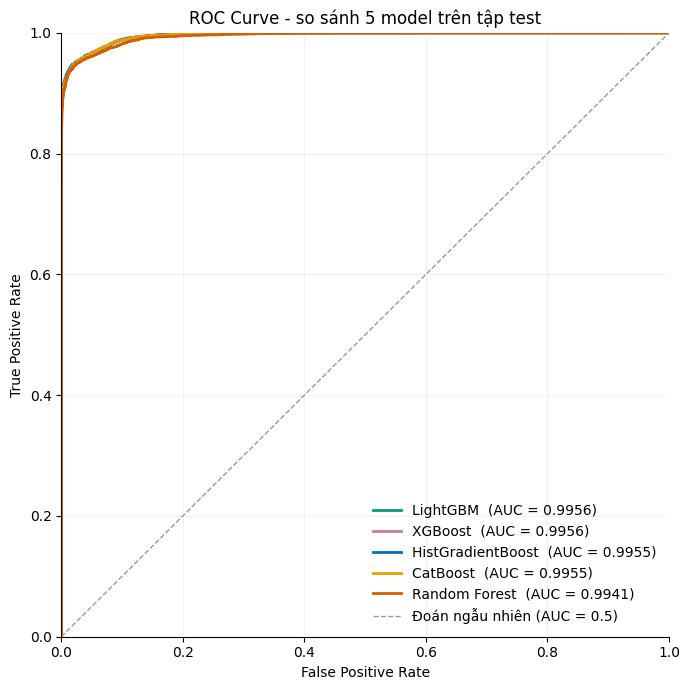

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Thứ tự màu đã qua kiểm định mù màu, gán cố định theo model - không xoay vòng
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7"]
colors = {name: PALETTE[i] for i, name in enumerate(model_paths)}

fig, ax = plt.subplots(figsize=(7, 7))

# Vẽ theo thứ tự AUC giảm dần để legend khớp bảng xếp hạng
for name in df_auc["Thuật toán"]:
    fpr, tpr, _ = roc_curve(y_test, proba_cache[name])
    auc = df_auc.loc[df_auc["Thuật toán"] == name, "ROC_AUC"].iloc[0]
    ax.plot(fpr, tpr, color=colors[name], linewidth=2,
            label=f"{name}  (AUC = {auc:.4f})")

# Đường tham chiếu: model đoán bừa
ax.plot([0, 1], [0, 1], color="#9a9a94", linewidth=1,
        linestyle="--", label="Đoán ngẫu nhiên (AUC = 0.5)")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - so sánh 5 model trên tập test")

# Trục và lưới lùi về sau, để đường cong nổi lên
ax.grid(True, linewidth=0.5, alpha=0.25)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()